# Part A – Data Loading and Initial Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


The Bank Marketing dataset used in this project is the complete dataset stored in the bank-full.csv file. It contains information collected from direct marketing campaigns carried out by a Portuguese banking institution. The data describes bank clients, the way they were contacted, and information from previous marketing campaigns.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


The complete dataset contains 45,211 rows and 17 columns. Each row represents a marketing campaign record associated with a bank client. It includes information about the client, the current contact, and previous marketing campaign activity. Sixteen columns are input features that describe the client, the contact process, and previous campaign activity. The remaining column, y, is the prediction target.

In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


The dataset includes client-related variables, such as age, job, marital status, education, account balance, and loan status. It also contains information about the current contact and previous marketing campaigns. The final column, y, records whether the client subscribed to a term deposit.

In [4]:
target_column = "y"

print("Target column:", target_column)
print("Target values:", df[target_column].unique())

Target column: y
Target values: <StringArray>
['no', 'yes']
Length: 2, dtype: str


The prediction target is the variable `y`. A value of `yes` means that the client subscribed to a term deposit, while a value of `no` means that the client did not subscribe. Therefore, this project is a binary classification problem.

In [5]:
target_column = "y"
input_features = df.drop(columns=[target_column])

numerical_columns = input_features.select_dtypes(include="number").columns.tolist()
categorical_columns = input_features.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical input features:")
print(numerical_columns)
print("Number of numerical input features:", len(numerical_columns))

print("\nCategorical input features:")
print(categorical_columns)
print("Number of categorical input features:", len(categorical_columns))

Numerical input features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Number of numerical input features: 7

Categorical input features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Number of categorical input features: 9


The dataset contains seven numerical input features: age, balance, day, duration, campaign, pdays, and previous. It also contains nine categorical input features: job, marital, education, default, housing, loan, contact, month, and poutcome. The target variable, y, is kept separate from the input features.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


The dataset contains both numerical and categorical variables. Seven columns are stored as integers and ten columns are stored as strings. All 17 columns contain 45,211 non-null values, so no missing values are detected at this stage.

In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


The dataset contains no missing values. All 17 columns have zero null values, so no missing-value treatment is required at this stage.

In [8]:
unknown_counts = (df == "unknown").sum()

print("Unknown values:")
print(unknown_counts[unknown_counts > 0])

Unknown values:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


The dataset contains "unknown" values in four categorical columns. The job column contains 288 unknown values, education contains 1,857, contact contains 13,020, and poutcome contains 36,959. These values are not missing values in the technical sense, but they represent unavailable or unspecified information and should be considered during preprocessing.

In [9]:
pdays_minus_one_count = (df["pdays"] == -1).sum()
pdays_minus_one_percentage = pdays_minus_one_count / len(df) * 100

print(f"Rows with pdays = -1: {pdays_minus_one_count:,}")
print(f"Percentage with pdays = -1: {pdays_minus_one_percentage:.2f}%")

Rows with pdays = -1: 36,954
Percentage with pdays = -1: 81.74%


The value -1 appears in the pdays column in 36,954 rows, representing 81.74% of the dataset. According to the dataset description, this value indicates that the client was not previously contacted during an earlier campaign. Therefore, it is a meaningful value rather than a missing value or a data-entry error.

In [10]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


The dataset contains no duplicate rows. Therefore, no duplicate records need to be removed at this stage.

In [11]:
print("Class distribution of y:")
print(df["y"].value_counts())

print("\nClass distribution percentages:")
print(df["y"].value_counts(normalize=True) * 100)

Class distribution of y:
y
no     39922
yes     5289
Name: count, dtype: int64

Class distribution percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


The target variable is imbalanced. Approximately 88.30% of the observations belong to the no class, while only 11.70% belong to the yes class. This imbalance should be taken into account during model training and evaluation.

## Part A – Analysis

1. Each row represents a marketing campaign record associated with a bank client. It includes information about the client, the current contact, and previous marketing campaign activity.

2. The prediction target is y, which indicates whether the client subscribed to a term deposit.

3. The target variable is imbalanced. Approximately 88.30% of the observations belong to the no class, while approximately 11.70% belong to the yes class.

4. The dataset contains seven numerical input features: age, balance, day, duration, campaign, pdays, and previous.

5. The dataset contains nine categorical input features: job, marital, education, default, housing, loan, contact, month, and poutcome. The target variable y is kept separate because it is the prediction target rather than an input feature.

6. No conventional missing values or duplicate rows were found. However, the columns job, education, contact, and poutcome contain unknown values. In addition, pdays = -1 appears in 36,954 rows, representing 81.74% of the dataset. According to the dataset description, this value indicates that the client was not previously contacted. Therefore, it is a meaningful value rather than a missing value or a data-entry error.

# Part B – Exploratory Data Analysis

The purpose of this section is to explore the main patterns in the Bank Marketing dataset before preprocessing and model training. The analysis includes summary statistics, categorical value counts, target class distribution, visualizations, and written insights based on the observed results.

In [12]:
numerical_summary = df[numerical_columns].describe().T.round(2)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


### Summary Statistics of Numerical Variables

The numerical variables show considerable variation across the dataset. The average client age is approximately 40.94 years, while the median age is 39 years. Half of the clients are between 33 and 48 years old.

The average account balance is approximately 1,362 euros, while the median is only 448 euros. This difference, together with the minimum balance of -8,019 euros and the maximum balance of 102,127 euros, suggests that the balance distribution is positively skewed and contains extreme values.

The median number of contacts made during the current campaign is two, although the maximum is 63 contacts. The median value of `pdays` is `-1`, which is consistent with the earlier finding that most clients had not been contacted during a previous campaign.

### Value Counts of Important Categorical Variables

The following tables present the frequency and percentage of the categories in the job, education, month, and previous campaign outcome variables.

In [13]:
categorical_variables = ["job", "education", "month", "poutcome"]

for column in categorical_variables:
    print(f"\nValue counts for {column}:")
    
    value_counts_table = pd.DataFrame({
        "Count": df[column].value_counts(),
        "Percentage": (
            df[column].value_counts(normalize=True) * 100
        ).round(2)
    })
    
    display(value_counts_table)


Value counts for job:


,Count,Percentage
job,,
blue-collar,9732,21.53
management,9458,20.92
technician,7597,16.80
admin.,5171,11.44
services,4154,9.19
retired,2264,5.01
self-employed,1579,3.49
entrepreneur,1487,3.29
unemployed,1303,2.88



Value counts for education:


,Count,Percentage
education,,
secondary,23202,51.32
tertiary,13301,29.42
primary,6851,15.15
unknown,1857,4.11



Value counts for month:


,Count,Percentage
month,,
may,13766,30.45
jul,6895,15.25
aug,6247,13.82
jun,5341,11.81
nov,3970,8.78
apr,2932,6.49
feb,2649,5.86
jan,1403,3.10
oct,738,1.63



Value counts for poutcome:


,Count,Percentage
poutcome,,
unknown,36959,81.75
failure,4901,10.84
other,1840,4.07
success,1511,3.34


The most common job categories are blue-collar, management, and technician, which represent 21.53%, 20.92%, and 16.80% of the dataset, respectively.

Secondary education is the most common education level and represents 51.32% of the observations, followed by tertiary education at 29.42%.

The campaign contacts are not distributed equally across the months. May contains the largest number of contacts, with 13,766 observations representing 30.45% of the dataset. In contrast, December contains only 214 observations, representing 0.47%.

The value `unknown` is the most common category in `poutcome` and appears in 81.75% of the observations. This is consistent with the earlier finding that most clients had not been contacted during a previous campaign.

### Visualization 1 – Target Class Distribution

The first visualization examines the distribution of the target variable `y`.

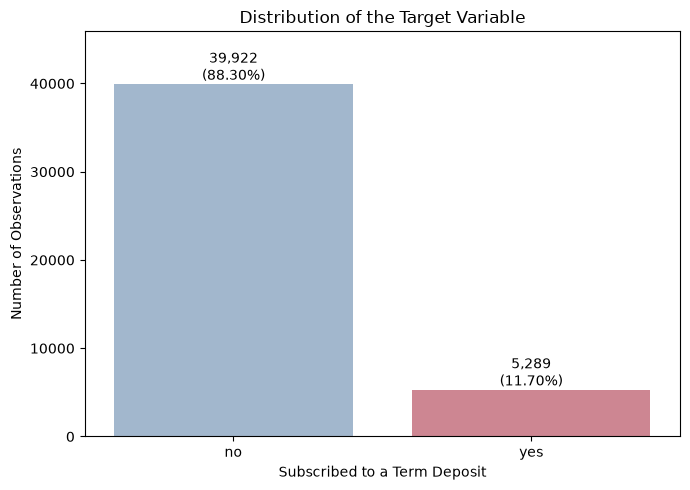

In [14]:
target_order = ["no", "yes"]

target_counts = df["y"].value_counts().reindex(target_order)
target_percentages = (
    df["y"].value_counts(normalize=True)
    .reindex(target_order) * 100
).round(2)

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="y",
    order=target_order,
    hue="y",
    palette={"no": "#9BB7D4", "yes": "#D97A8A"},
    legend=False
)

plt.title("Distribution of the Target Variable")
plt.xlabel("Subscribed to a Term Deposit")
plt.ylabel("Number of Observations")

for index, category in enumerate(target_order):
    count = target_counts.loc[category]
    percentage = target_percentages.loc[category]
    
    ax.text(
        index,
        count + 500,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center"
    )

plt.ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

The target variable is clearly imbalanced. A total of 39,922 observations, representing 88.30% of the dataset, belong to the `no` class. Only 5,289 observations, representing 11.70%, belong to the `yes` class. This imbalance should be considered during model training and evaluation because the majority class is substantially larger than the minority class.

Because of this imbalance, accuracy alone may be misleading, since a model could achieve high accuracy mainly by predicting the majority class. Therefore, precision, recall, F1-score, and the confusion matrix should also be considered when evaluating the models.

### Visualization 2 – Age Distribution

The following histogram presents the distribution of client ages.

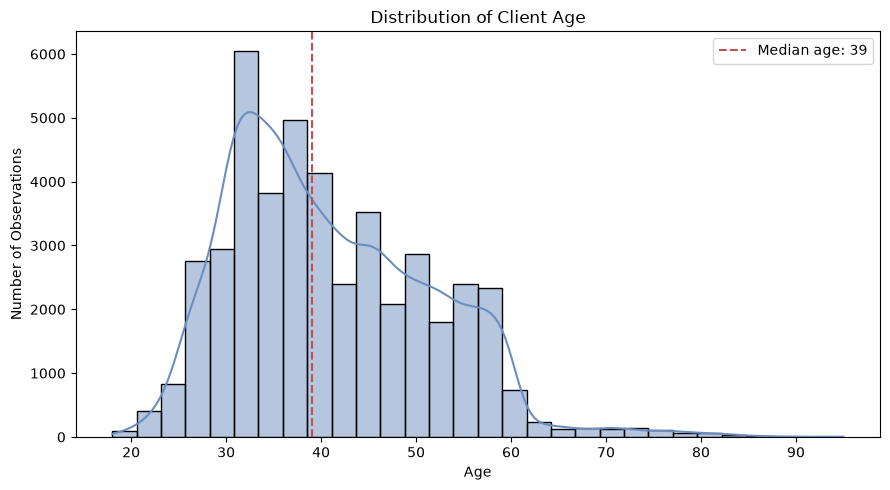

In [15]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="#6C8EBF"
)

plt.axvline(
    df["age"].median(),
    color="#C44E52",
    linestyle="--",
    label=f"Median age: {df['age'].median():.0f}"
)

plt.title("Distribution of Client Age")
plt.xlabel("Age")
plt.ylabel("Number of Observations")
plt.legend()
plt.tight_layout()
plt.show()

Most clients are concentrated in the adult age range, with a median age of 39 years. Half of the clients are between 33 and 48 years old. The distribution has a longer right tail because the dataset also contains a smaller number of considerably older clients, with ages reaching up to 95 years.

### Visualization 3 – Subscription Rate by Job Type

This visualization compares the percentage of clients who subscribed to a term deposit across the different job categories.

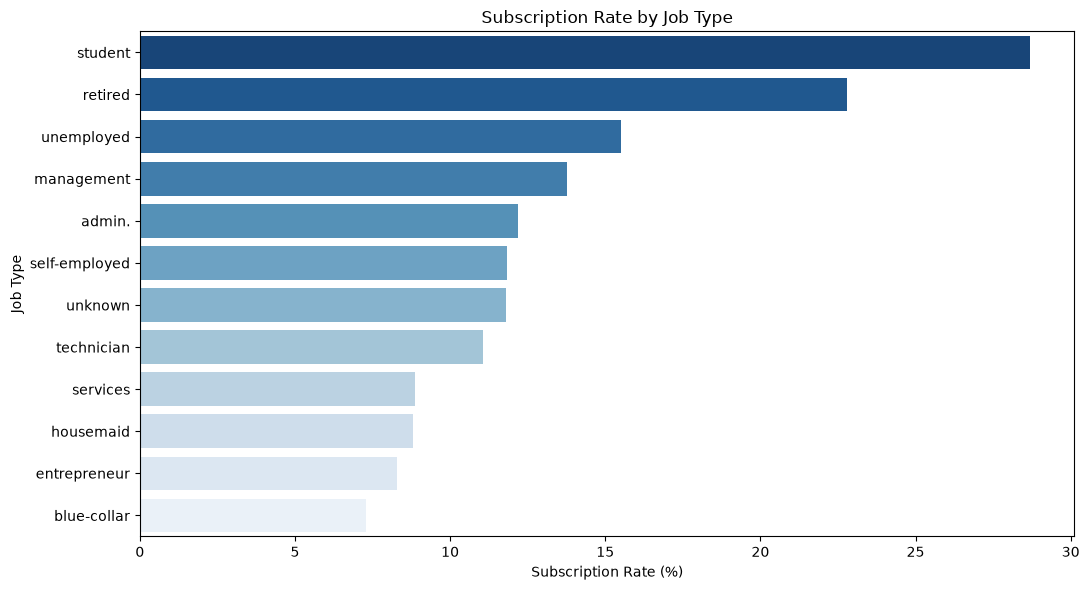

,job,Number_of_Clients,Subscription_Rate
8,student,938,28.68
5,retired,2264,22.79
10,unemployed,1303,15.50
4,management,9458,13.76
0,admin.,5171,12.20
6,self-employed,1579,11.84
11,unknown,288,11.81
9,technician,7597,11.06
7,services,4154,8.88
3,housemaid,1240,8.79


In [16]:
job_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("job", as_index=False)
      .agg(
          Number_of_Clients=("subscribed", "size"),
          Subscription_Rate=("subscribed", "mean")
      )
)

job_subscription["Subscription_Rate"] *= 100

job_subscription = job_subscription.sort_values(
    "Subscription_Rate",
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=job_subscription,
    x="Subscription_Rate",
    y="job",
    hue="job",
    palette="Blues_r",
    legend=False
)

plt.title("Subscription Rate by Job Type")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()

display(job_subscription.round(2))

Subscription rates vary considerably across job categories. Students have the highest observed subscription rate at approximately 28.68%, followed by retired clients at approximately 22.79%. In contrast, blue-collar clients have the lowest observed subscription rate at approximately 7.27%.

However, these results should be interpreted together with the number of clients in each category. The student category contains only 938 clients, while the blue-collar category contains 9,732 clients. Therefore, a higher subscription rate does not necessarily indicate a larger total number of subscribers.

### Visualization 4 – Subscription Rate by Month

The following visualization examines whether the observed subscription rate differs across campaign months.

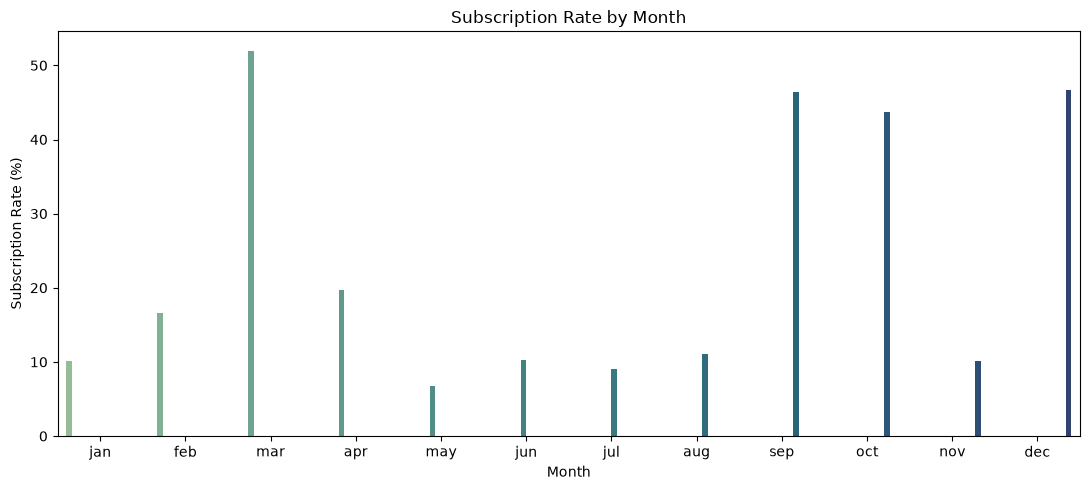

,month,Number_of_Clients,Subscription_Rate
4,jan,1403,10.12
3,feb,2649,16.65
7,mar,477,51.99
0,apr,2932,19.68
8,may,13766,6.72
6,jun,5341,10.22
5,jul,6895,9.09
1,aug,6247,11.01
11,sep,579,46.46
10,oct,738,43.77


In [17]:
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("month", as_index=False)
      .agg(
          Number_of_Clients=("subscribed", "size"),
          Subscription_Rate=("subscribed", "mean")
      )
)

month_subscription["Subscription_Rate"] *= 100

month_subscription["month"] = pd.Categorical(
    month_subscription["month"],
    categories=month_order,
    ordered=True
)

month_subscription = month_subscription.sort_values("month")

plt.figure(figsize=(11, 5))

sns.barplot(
    data=month_subscription,
    x="month",
    y="Subscription_Rate",
    hue="month",
    palette="crest",
    legend=False
)

plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.show()

display(month_subscription.round(2))

The highest observed subscription rate appears in March at approximately 51.99%. December, September, and October also have relatively high rates of 46.73%, 46.46%, and 43.77%, respectively.

However, these months contain considerably fewer campaign contacts than months such as May, July, and August. May contains the largest number of observations, with 13,766 contacts, but has the lowest subscription rate at approximately 6.72%. Therefore, the monthly subscription rates should be interpreted together with the number of observations and should not be treated as evidence that the month itself caused the differences.

### Visualization 5 – Subscription Rate by Previous Campaign Outcome

This visualization compares the current subscription rate according to the recorded outcome of the previous marketing campaign.

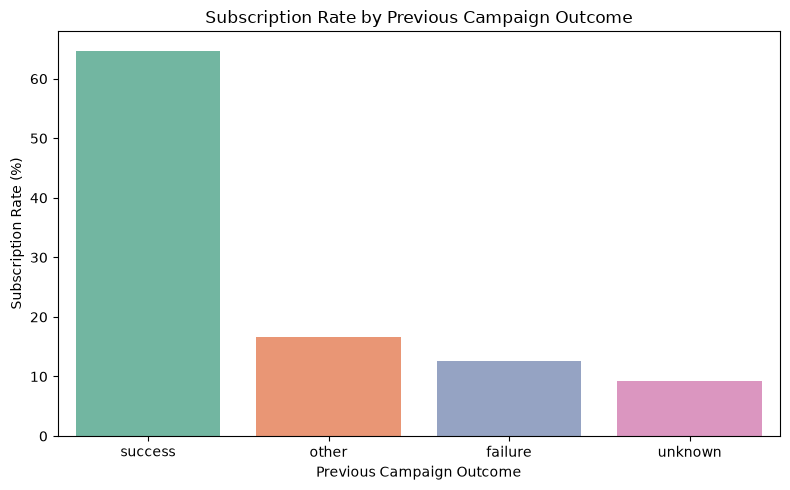

,poutcome,Number_of_Clients,Subscription_Rate
2,success,1511,64.73
1,other,1840,16.68
0,failure,4901,12.61
3,unknown,36959,9.16


In [18]:
poutcome_subscription = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("poutcome", as_index=False)
      .agg(
          Number_of_Clients=("subscribed", "size"),
          Subscription_Rate=("subscribed", "mean")
      )
)

poutcome_subscription["Subscription_Rate"] *= 100

poutcome_subscription = poutcome_subscription.sort_values(
    "Subscription_Rate",
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=poutcome_subscription,
    x="poutcome",
    y="Subscription_Rate",
    hue="poutcome",
    palette="Set2",
    legend=False
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.tight_layout()
plt.show()

display(poutcome_subscription.round(2))

Clients whose previous campaign outcome was recorded as `success` have a substantially higher current subscription rate of approximately 64.73%. The observed rates are considerably lower for `other`, `failure`, and `unknown` outcomes.

This result indicates a strong association between previous campaign success and current subscription behavior. However, most observations belong to the `unknown` category, so previous campaign information is not available for the majority of clients. The observed relationship should also be interpreted as an association rather than proof that previous success directly caused the current subscription.

## Part B – Main EDA Insights

1. **The target variable is imbalanced.** Approximately 88.30% of the observations belong to the `no` class, while only 11.70% belong to the `yes` class. This imbalance should be considered during model training and evaluation.

2. **Several numerical variables have wide ranges and extreme values.** For example, account balance ranges from -8,019 to 102,127 euros, while its median is only 448 euros. The number of campaign contacts reaches 63, although its median is only two contacts.

3. **Subscription rates differ across job categories.** Students and retired clients have the highest observed subscription rates, at approximately 28.68% and 22.79%, respectively. However, these categories contain fewer clients than larger groups such as blue-collar, management, and technician clients.

4. **Subscription rates vary considerably across campaign months.** March, December, September, and October have the highest observed rates, while May contains the largest number of contacts but has the lowest subscription rate. These comparisons should be interpreted carefully because the number of observations differs greatly between months.

5. **Previous campaign success is strongly associated with current subscription.** Clients with a successful previous campaign outcome have an observed subscription rate of approximately 64.73%. However, most clients have an `unknown` previous outcome, which limits the availability of this information.

# Part C – Data Cleaning and Preprocessing

## Separation of Features and Target

In [19]:
X = df.drop(columns=["y", "duration"]).copy()
y = df["y"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 15)
y shape: (45211,)


## Separation of Features and Target and Exclusion of Duration

The dataset was separated into input features (`X`) and the target variable (`y`). `X` contains the variables used to predict whether a client will subscribe to a term deposit, while `y` represents the subscription outcome.

The `duration` feature was excluded from the main modeling dataset because it represents the length of the phone call and is only known after the call has taken place. Since the purpose of the system is to identify potential subscribers before contacting them, including this variable could introduce data leakage and produce unrealistically optimistic model results. Therefore, the main models are trained without `duration` to create a more realistic pre-call prediction system.

In [20]:
y = y.map({"yes": 1, "no": 0})

print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


## Target Encoding

The target variable `y` was converted from categorical values to numerical values. The value `yes` was encoded as `1`, and the value `no` was encoded as `0`, so the target can be used by machine learning models.

In [21]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Identification of Numerical and Categorical Features

The input features were separated into numerical and categorical variables based on their data types. This separation is necessary because each type of variable requires a different preprocessing method before training the machine learning models.

In [22]:
unknown_counts = (X[categorical_features] == "unknown").sum()
unknown_counts = unknown_counts[unknown_counts > 0]

print(unknown_counts)

job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


In [23]:
X[categorical_features] = X[categorical_features].replace("unknown", "Unknown")

print((X[categorical_features] == "unknown").sum().sum())

0


## Handling of Unknown Values

The categorical features were checked for `unknown` values. These values were found in `job`, `education`, `contact`, and `poutcome`. Since some of these variables contain a large number of `unknown` values, removing the corresponding observations would result in a substantial loss of data. Therefore, the values were retained as a separate category named `Unknown`, allowing them to be handled later by the categorical encoding process.


In [24]:
from sklearn.preprocessing import OneHotEncoder

categorical_encoder = OneHotEncoder(handle_unknown="ignore")

print(categorical_encoder)

OneHotEncoder(handle_unknown='ignore')


## Encoding of Categorical Variables

Categorical features will be encoded using `OneHotEncoder`. The encoder is configured with `handle_unknown="ignore"` so that categories that may appear in the test data but were not seen during training will not cause errors. The encoder will be fitted only on the training data to prevent data leakage.

In [25]:
from sklearn.preprocessing import StandardScaler

numerical_scaler = StandardScaler()

print(numerical_scaler)

StandardScaler()


## Scaling of Numerical Variables for KNN

Numerical features will be standardized using `StandardScaler`. Scaling is important for the KNN algorithm because it is based on distances between observations, and variables with larger numerical ranges could otherwise have a stronger influence on the model. The scaler will be fitted only on the training data to prevent data leakage.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (36168, 15)
X_test shape: (9043, 15)
y_train shape: (36168,)
y_test shape: (9043,)


## Train/Test Split

The dataset was divided into training and test sets using an 80/20 split. A `random_state` of 42 was used to ensure reproducibility, and `stratify=y` was applied to preserve the class distribution of the target variable in both sets.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

X_train_preprocessed = preprocessing_pipeline.fit_transform(X_train)
X_test_preprocessed = preprocessing_pipeline.transform(X_test)

print("X_train preprocessed shape:", X_train_preprocessed.shape)
print("X_test preprocessed shape:", X_test_preprocessed.shape)

X_train preprocessed shape: (36168, 50)
X_test preprocessed shape: (9043, 50)


## Prevention of Data Leakage

A `ColumnTransformer` and `Pipeline` were used to apply preprocessing consistently to the numerical and categorical features. The preprocessing pipeline was fitted only on the training data using `fit_transform`, while the test data was transformed separately using `transform`. This prevents information from the test set from influencing the preprocessing steps and avoids data leakage.

In [28]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", decision_tree_preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

print(decision_tree_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model', DecisionTreeClassifier(random_state=42))])


## Decision Tree Preprocessing Pipeline

A preprocessing pipeline was created for the Decision Tree model. Numerical features are passed without scaling because Decision Trees are not distance-based models, while categorical features are encoded using `OneHotEncoder`. The preprocessing steps and the classifier are combined in a single `Pipeline` to ensure consistent processing of the training and test data and to reduce the risk of data leakage.

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", knn_preprocessor),
        ("model", KNeighborsClassifier())
    ]
)

print(knn_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model', KNeighborsClassifier())])


## KNN Preprocessing Pipeline

A preprocessing pipeline was created for the KNN model. Numerical features are standardized using `StandardScaler` because KNN is based on distances between observations. Categorical features are encoded using `OneHotEncoder`. The preprocessing steps and the classifier are combined in a single `Pipeline` to ensure consistent preprocessing and to reduce the risk of data leakage.

# Part D – Train/Test Split

The purpose of this section is to divide the dataset into separate training and test sets. The training set will be used to train the machine learning models, while the test set will be used to evaluate their performance on unseen data. 
 

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (36168, 15)
X_test shape: (9043, 15)
y_train shape: (36168,)
y_test shape: (9043,)


## Explanation of the Train/Test Split

The dataset was divided into training and test sets using an 80/20 split. The training set contains 80% of the observations and will be used to train the machine learning models. The remaining 20% forms the test set and will be used to evaluate how well the trained models perform on unseen data.

A `random_state` value of 42 was used to make the split reproducible, meaning that the same observations will be assigned to the training and test sets whenever the notebook is executed again.

The parameter `stratify=y` was used because the target variable is imbalanced. Approximately 88.30% of the observations belong to the `no` class, while only 11.70% belong to the `yes` class. Stratified splitting preserves approximately the same class distribution in both the training and test sets, allowing the models to be trained and evaluated on representative samples.

In [31]:
print("Training set class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set class distribution:
y
0    88.3
1    11.7
Name: proportion, dtype: float64

Test set class distribution:
y
0    88.3
1    11.7
Name: proportion, dtype: float64


# Part E – Model 1: Decision Tree Classifier

The purpose of this section is to train the first classification model of the project, a Decision Tree Classifier. The model is trained on the training set created in Part D, using the Decision Tree preprocessing pipeline prepared in Part C. The performance of the model on the test set is not measured in this section; both models are evaluated and compared in Part G.

In [32]:
from sklearn.tree import DecisionTreeClassifier

# The Decision Tree preprocessing pipeline from Part C is reused, together with
# the hyperparameters selected for this project.
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", decision_tree_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# The pipeline is fitted on the training set only, so both the categorical
# encoding and the tree structure are learned exclusively from the training data.
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

## Model Configuration and Training

The Decision Tree was trained inside the pipeline defined in Part C. Numerical features are passed through without scaling, and categorical features are encoded using `OneHotEncoder`. Combining the preprocessing steps and the classifier in a single `Pipeline` ensures that exactly the same transformations are applied to the training and the test data. Because the pipeline is fitted with `fit(X_train, y_train)`, the encoder learns its categories only from the training set, which prevents data leakage. The model is trained on the 15 input features defined in Part C, which exclude `duration`, since the length of a call is only known after the call has already taken place.

The following hyperparameters were used:

- `max_depth=5` limits the tree to five consecutive splits from the root to a leaf, so every prediction is based on at most five questions. This keeps the model small enough to be read and explained, and it restricts how closely the tree can fit the training data.
- `min_samples_leaf=20` requires every leaf to contain at least 20 training observations. This prevents the tree from creating rules that are based on a very small number of clients and that would mostly reflect noise.
- `random_state=42` fixes the random component of the algorithm, which is used for example when several candidate splits are equally good. The same tree is therefore produced every time the notebook is executed. The same value was used for the train/test split, so the whole workflow remains reproducible.
- `class_weight="balanced"` gives a higher weight to the minority class during training. Since only 11.70% of the clients subscribed, an unweighted tree could reach a high accuracy simply by predicting `no` for almost every client, and this parameter reduces that tendency.

These are the parameter values suggested in the assignment, and they were kept because they fit this dataset: the target variable is imbalanced and the encoded feature space is relatively large, so a restricted and class-weighted tree is both interpretable and less likely to overfit. No hyperparameter search was performed.

In [33]:
decision_tree_model = decision_tree_pipeline.named_steps["model"]
decision_tree_feature_names = decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Number of features after preprocessing:", len(decision_tree_feature_names))
print("Depth of the trained tree:", decision_tree_model.get_depth())
print("Number of leaves in the trained tree:", decision_tree_model.get_n_leaves())
print("Feature importance values available:", len(decision_tree_model.feature_importances_))

Number of features after preprocessing: 50
Depth of the trained tree: 5
Number of leaves in the trained tree: 29
Feature importance values available: 50


## Verification of the Trained Model

The trained classifier was extracted from the pipeline and stored in `decision_tree_model`, and the names of the columns created by the preprocessing step were stored in `decision_tree_feature_names`. The printed output confirms that the model was trained successfully: the tree reached the maximum allowed depth of five levels, it ends in a limited number of leaves, and it provides one feature importance value for every column produced by the preprocessing step.

These objects are kept for the later sections of the project. The fitted `decision_tree_pipeline` is evaluated on the test set in Part G and compared with the KNN model, and the feature importance values together with the feature names are used for the feature analysis in the recommendation module in Part H. No evaluation metrics are computed here, because accuracy, precision, recall, the F1-score, and the confusion matrix belong to the evaluation section in Part G.

## How a Decision Tree Classifier Works

A Decision Tree classifies an observation by asking a sequence of simple questions about the input features. Starting from the root, the algorithm examines the available features and the possible split points and selects the split that best separates subscribers from non-subscribers, measured by an impurity criterion (the Gini index, which is the default in scikit-learn). Each of the two resulting groups is then split again in the same way, and the process continues recursively until a stopping condition is reached. In this project the process stops after five levels, or when a further split would leave fewer than 20 clients in a leaf. Each leaf stores the class distribution of the training observations that reached it, and a new client is classified by following the questions from the root to a leaf.

A Decision Tree can model non-linear relationships because it divides the feature space into rectangular regions instead of fitting a single global equation, and it makes no assumption that the relationship between a feature and the target is linear. It can also represent interactions between variables, since different branches of the tree can use different questions. For example, the effect of the contact `month` can differ between clients whose previous campaign outcome `poutcome` was `success` and clients for whom it is `Unknown`, because these two groups follow different paths through the tree. A linear model would require such interactions to be created manually.

A Decision Tree is relatively interpretable because the fitted model is simply a set of if-then rules that can be read directly. Since the depth is limited to five, every prediction of this model can be explained using at most five conditions on real business variables such as `poutcome`, `contact`, `month`, `housing`, or `age`, which makes the logic easy to present to the marketing department. In addition, the `feature_importances_` attribute of the trained tree measures how much each feature contributed to reducing impurity across all splits, which provides a ranking of the most influential variables and is used later in the recommendation module.

## Overfitting, Tree Depth, and Feature Scaling

A Decision Tree can overfit if it becomes too deep. When the tree is allowed to grow without restrictions, it continues splitting until the leaves are almost pure, which means that it eventually describes individual training clients rather than general patterns. Such a tree fits the training data very well but also learns the noise in it, and its performance on new clients is usually much weaker. This risk is realistic in this project, since the training set contains 36,168 observations and 50 columns after one-hot encoding, which would allow a very large tree to be built.

Overfitting is reduced here by the two constraints described above. Limiting the depth with `max_depth=5` stops the growth of the tree after five levels, and requiring a minimum number of samples in each leaf with `min_samples_leaf=20` prevents rules that are supported by only a few clients. Other common ways to control overfitting include increasing `min_samples_split`, applying cost-complexity pruning through `ccp_alpha`, or training on a larger amount of data.

There is a trade-off between a very deep tree and a shallow tree. A deep tree can represent more complex rules and reaches a higher accuracy on the training data, but it is difficult to read and it generalizes poorly. A shallow tree, such as the one used in this project, is easier to interpret and more stable on new data, but it may underfit, which means that it can miss finer patterns and reach a lower accuracy. A depth of five was chosen as a compromise between interpretability and predictive ability, which is appropriate for a marketing model whose decisions must be explained to business users.

Decision Trees do not require feature scaling. Each split compares a single feature with a threshold, and the ordering of the values of a feature does not change when the feature is rescaled, so standardizing `balance` or `age` would produce the same tree. This is the reason why the Decision Tree preprocessor defined in Part C passes the numerical features through unchanged, while the KNN preprocessor standardizes them with `StandardScaler`, since KNN is distance-based and is affected by the ranges of the features.

# Part F – Model 2: k-Nearest Neighbors Classifier

The purpose of this section is to train the second classification model of the project, a k-Nearest Neighbors (KNN) classifier. The model is trained on the same training set created in Part D and uses the KNN preprocessing pipeline prepared in Part C, in which the numerical features are standardized. As in Part E, the performance of the model on the test set is not measured in this section; both models are evaluated and compared in Part G.

In [34]:
from sklearn.neighbors import KNeighborsClassifier

# The KNN preprocessing pipeline from Part C is reused, together with the
# number of neighbours selected for this project.
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", knn_preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

# The pipeline is fitted on the training set only, so the scaler and the encoder
# learn their values exclusively from the training data.
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

## Model Configuration and Training

The KNN classifier was trained inside the preprocessing pipeline defined in Part C. The numerical features are standardized with `StandardScaler`, the categorical features are encoded with `OneHotEncoder`, and the classifier is placed in the same `Pipeline`, so that exactly the same transformations are applied to the training and the test data.

Because the pipeline is fitted with `fit(X_train, y_train)`, the scaler computes the mean and the standard deviation of each numerical feature from the training set only, and the encoder learns its categories from the training set only. The test set does not influence these values, which prevents data leakage. In Part G the test data will be transformed using the same values that were learned here from the training data.

The model uses the same 15 input features as the Decision Tree in Part E. The feature `duration` remains excluded, as decided in Part C, because the length of a call is only known after the call has already taken place and the system is intended to predict subscription before the client is contacted.

The parameter `n_neighbors=5` sets the number of neighbours used for a prediction. This is the configuration suggested in the assignment, and it was kept because it is a reasonable middle value: it is not so small that a single unusual client determines the prediction, and not so large that small groups of similar clients disappear inside a much wider neighbourhood. No hyperparameter search was performed.

`KNeighborsClassifier` has no `random_state` parameter, because the algorithm contains no random component: the same training data always produce the same neighbours. Reproducibility of the workflow is ensured by the fixed `random_state=42` used in the train/test split in Part D.

In [35]:
knn_model = knn_pipeline.named_steps["model"]
knn_feature_names = knn_pipeline.named_steps["preprocessor"].get_feature_names_out()
knn_scaler = knn_pipeline.named_steps["preprocessor"].named_transformers_["num"]

print("Number of features after preprocessing:", len(knn_feature_names))
print("Number of neighbours (k):", knn_model.n_neighbors)
print("Number of training observations stored by the model:", knn_model.n_samples_fit_)

# The scaler stores the mean and the standard deviation of every numerical
# feature, learned from the training data only.
scaling_values = pd.DataFrame(
    {
        "mean_learned_from_training_data": knn_scaler.mean_,
        "standard_deviation_learned_from_training_data": knn_scaler.scale_
    },
    index=numerical_features
).round(2)

print("\nScaling values learned for the numerical features:")
print(scaling_values)

Number of features after preprocessing: 50
Number of neighbours (k): 5
Number of training observations stored by the model: 36168

Scaling values learned for the numerical features:
          mean_learned_from_training_data  \
age                                 40.89   
balance                           1365.49   
day                                 15.82   
campaign                             2.76   
pdays                               40.16   
previous                             0.58   

          standard_deviation_learned_from_training_data  
age                                               10.63  
balance                                         3068.50  
day                                                8.33  
campaign                                           3.10  
pdays                                            100.16  
previous                                           2.41  


## Verification of the Trained Model

The trained classifier was extracted from the pipeline and stored in `knn_model`, and the names of the columns produced by the preprocessing step were stored in `knn_feature_names`. The printed output confirms that the model was trained successfully: the preprocessing step produces 50 columns, the model uses five neighbours, and the number of stored training observations matches the size of the training set created in Part D.

The table shows the mean and the standard deviation that `StandardScaler` learned for each numerical feature. These values come from the training data only, which confirms both that scaling was actually applied and that the test set did not influence the scaler. The table also illustrates how different the original scales are: the standard deviation of `balance` is far larger than the standard deviation of `previous`, which is exactly the situation that makes scaling necessary for a distance-based model.

The fitted `knn_pipeline` is kept for the later sections of the project. In Part G it is used to predict the classes of the test set and to compute the evaluation metrics and the confusion matrix, which are then compared with the results of the Decision Tree. No evaluation metrics are computed here, because accuracy, precision, recall, the F1-score, and the confusion matrix belong to the evaluation section in Part G.

## How the k-Nearest Neighbors Classifier Works

KNN classifies a new observation by looking at the observations that are closest to it. Every client is represented as a point whose position is determined by the values of the columns produced by the preprocessing step, so in this project each client is a point described by 50 values. The neighbours of a client are simply the training clients whose values are the most similar, meaning that their points are the closest ones.

To classify a client, the algorithm measures the distance between that client and every client in the training set, selects the `n_neighbors` closest training clients, and predicts the class held by the majority of them. The distance is computed with the Euclidean distance, which is the default in scikit-learn: the differences between the two clients are computed column by column, and these differences are combined into a single number that expresses how far apart the two clients are.

KNN is therefore a distance-based algorithm. Unlike the Decision Tree of Part E, it does not build a set of rules during training. It mainly stores the training observations, and the actual work is performed at prediction time, when the distances to the stored observations are calculated.

## The Value of k

The value of `k`, given by the parameter `n_neighbors`, is the number of nearby training observations that the model consults before making a prediction. In this project `n_neighbors=5`, which means that for every client the model finds the five most similar training clients and predicts the class that appears most often among those five. For example, if three of the five nearest training clients subscribed to a term deposit, the client is predicted as `yes`.

Different values of `k` change the behaviour of the model. A small value, such as `k=1` or `k=3`, means that the prediction relies on very few observations, so a single unusual or mislabelled client can determine the result and the model becomes sensitive to noise. A larger value, such as `k=11`, averages the decision over more clients and therefore produces smoother and more stable predictions, but small local groups with a distinctive behaviour can be outvoted by the surrounding majority. This second effect is relevant in this dataset, because only 11.70% of the clients subscribed, so the neighbourhood of a client frequently contains a majority of non-subscribers.

The value `k=5` was selected as a balance between these two effects, following the configuration suggested in the assignment. This discussion is conceptual: no experiments with other values of `k` were performed, so no conclusion is drawn here about which value would produce the best measured results on this dataset.

## Feature Scaling and High-Dimensional Encoded Data

Feature scaling is necessary for KNN because the model is distance-based, and the size of the numbers in a column directly determines how much that column contributes to the distance. Without scaling, numerical features with large ranges may dominate the distance calculation. In this dataset `balance` is measured in euros and ranges from -8,019 to 102,127, so the difference between two clients can be thousands of units, while the difference in `age` is usually a few tens of units and the difference in `previous` only a few units. The distance between two clients would then be decided almost entirely by their account balance, and the remaining features would have almost no influence.

`StandardScaler` solves this by subtracting the mean and dividing by the standard deviation of each numerical feature, using the values learned from the training data that are shown in the verification table above. After this transformation every numerical feature has a mean of approximately zero and a standard deviation of approximately one in the training set, so all features contribute to the distance on a comparable scale. This is the reason why the KNN preprocessor standardizes the numerical features while the Decision Tree preprocessor of Part E passes them through unchanged: the tree compares one feature with a threshold at a time and is therefore unaffected by the scale.

KNN may also be less effective on high-dimensional encoded data. After one-hot encoding, each categorical feature is replaced by one column per category, so the 15 original input features become 50 columns, as printed in the verification cell above. Every additional column adds another term to the distance calculation, which is what is meant by a large, or high-dimensional, feature space. As the number of columns grows, the distances between points become increasingly similar to one another, so the difference between the nearest neighbours and the more distant observations becomes less informative. In addition, the one-hot columns contain only the values 0 and 1, so a single category can contribute at most one unit to the distance, while many such columns together can outweigh the standardized numerical features. For these reasons the neighbourhood used by KNN in this project is less meaningful than it would be in a small feature space.

# Part G – Model Evaluation and Comparison

The purpose of this section is to evaluate the Decision Tree and k-Nearest Neighbors classifiers on the test set. Since the target variable is imbalanced, model performance will not be assessed using accuracy alone. Precision, recall, F1-score, and the confusion matrix will also be examined in order to understand how well each model identifies clients who actually subscribe to a term deposit. 


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Generate predictions on the test set
decision_tree_predictions = decision_tree_pipeline.predict(X_test)
knn_predictions = knn_pipeline.predict(X_test)

print("Predictions were generated successfully.")
print("Decision Tree predictions:", len(decision_tree_predictions))
print("KNN predictions:", len(knn_predictions))
print("Test observations:", len(y_test))

Predictions were generated successfully.
Decision Tree predictions: 9043
KNN predictions: 9043
Test observations: 9043


In [37]:
# Calculate evaluation metrics for both models

decision_tree_metrics = {
    "Accuracy": accuracy_score(y_test, decision_tree_predictions),
    "Precision": precision_score(y_test, decision_tree_predictions),
    "Recall": recall_score(y_test, decision_tree_predictions),
    "F1-score": f1_score(y_test, decision_tree_predictions)
}

knn_metrics = {
    "Accuracy": accuracy_score(y_test, knn_predictions),
    "Precision": precision_score(y_test, knn_predictions),
    "Recall": recall_score(y_test, knn_predictions),
    "F1-score": f1_score(y_test, knn_predictions)
}

comparison_table = pd.DataFrame(
    [decision_tree_metrics, knn_metrics],
    index=["Decision Tree", "kNN"]
)

comparison_table.round(4)

,Accuracy,Precision,Recall,F1-score
Decision Tree,0.7958,0.3005,0.5614,0.3914
kNN,0.8874,0.5529,0.1975,0.2911


In [38]:
# Detailed classification reports for both models

print("Decision Tree Classification Report")
print("=" * 40)
print(classification_report(
    y_test,
    decision_tree_predictions,
    target_names=["No", "Yes"]
))

print("\nkNN Classification Report")
print("=" * 40)
print(classification_report(
    y_test,
    knn_predictions,
    target_names=["No", "Yes"]
))

Decision Tree Classification Report
              precision    recall  f1-score   support

          No       0.93      0.83      0.88      7985
         Yes       0.30      0.56      0.39      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.69      0.63      9043
weighted avg       0.86      0.80      0.82      9043


kNN Classification Report
              precision    recall  f1-score   support

          No       0.90      0.98      0.94      7985
         Yes       0.55      0.20      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.61      9043
weighted avg       0.86      0.89      0.86      9043



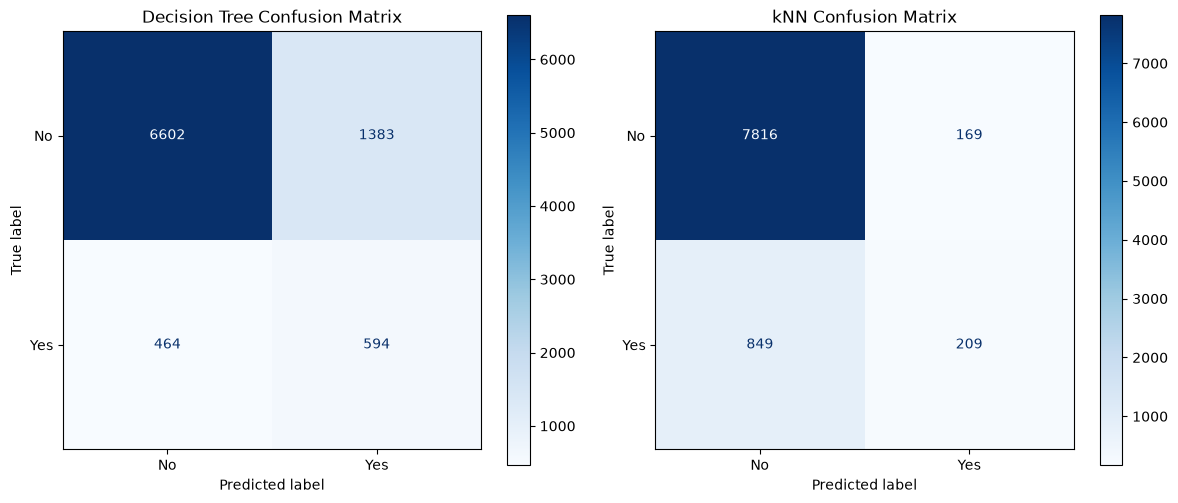

In [39]:
# Confusion matrices for both models

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_predictions,
    display_labels=["No", "Yes"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Decision Tree Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    display_labels=["No", "Yes"],
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("kNN Confusion Matrix")

plt.tight_layout()
plt.show()

### Model Evaluation and Comparison

The two models show different strengths when predicting whether a client will subscribe to a term deposit.

The Decision Tree achieved an accuracy of 0.7958, precision of 0.3005, recall of 0.5614, and an F1-score of 0.3914 for the positive class. In comparison, kNN achieved a higher accuracy of 0.8874 and a higher precision of 0.5529, but its recall was much lower at 0.1975, with an F1-score of 0.2911.

The confusion matrices help explain this difference. The Decision Tree correctly identified 594 clients who subscribed, while missing 464 subscribers. However, it also incorrectly classified 1,383 non-subscribers as subscribers. In contrast, kNN produced only 169 false positives, but it missed 849 actual subscribers and correctly identified only 209 of them.

These results show why accuracy alone is not sufficient for this dataset. Since the target variable is imbalanced, the high accuracy of kNN is strongly influenced by its ability to classify the majority "No" class. The Decision Tree has lower overall accuracy and precision, but it identifies a much larger proportion of the actual subscribers.

Therefore, the choice between the models depends on the bank's objective. If identifying as many potential subscribers as possible is important, the higher recall of the Decision Tree is useful. If reducing unnecessary contacts with clients who are unlikely to subscribe is more important, the higher precision of kNN may be preferable. The business implications of these errors will be examined further in the recommendation and business interpretation sections.

# Part H – Data-Driven Recommendation Module

This section turns the dataset and the trained models from the previous parts into practical recommendations for the bank. The recommendations are based on computed historical subscription rates, Decision Tree feature importance, and the test-set predictions of both models from Part G.

### 1. Best Customer Segments

Customer segments are compared according to their historical subscription rates. The subscription rate of a group is the share of clients in that group who subscribed to a term deposit. To avoid conclusions based on very small groups, only segments with at least 100 clients are reported.

In [40]:
# Historical subscription rate of every customer and campaign segment.
# The rate of a group is the share of its clients who answered "yes". It is
# computed from the dataset alone, without using either trained model.
segment_df = df.copy()

segment_df["y_numeric"] = (
    segment_df["y"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"no": 0, "yes": 1, "0": 0, "1": 1})
)

overall_subscription_rate = segment_df["y_numeric"].mean() * 100

# The rate is computed for every category of every categorical column and kept
# in `segment_rates`, which is reused as evidence in section 2.
segment_rates = []

for column in categorical_features:
    segment_table = (
        segment_df.groupby(column)["y_numeric"]
        .agg(["count", "mean"])
        .reset_index()
    )

    segment_table["mean"] = segment_table["mean"] * 100

    segment_table["Segment Variable"] = column

    segment_table = segment_table.rename(columns={
        column: "Segment Value",
        "count": "Number of Clients",
        "mean": "Subscription Rate (%)"
    })

    segment_rates.append(
        segment_table[
            [
                "Segment Variable",
                "Segment Value",
                "Number of Clients",
                "Subscription Rate (%)"
            ]
        ]
    )

segment_rates = pd.concat(segment_rates, ignore_index=True)

# Section 1 reports the segment variables listed in the assignment. Groups with
# fewer than 100 clients are excluded, so that a very small group cannot produce
# a misleading subscription rate.
segment_columns = ["job", "education", "marital", "housing", "loan", "month", "poutcome"]
minimum_segment_size = 100

reported_segments = segment_rates[segment_rates["Segment Variable"].isin(segment_columns)]
small_segments = reported_segments[reported_segments["Number of Clients"] < minimum_segment_size]

customer_segments = (
    reported_segments[reported_segments["Number of Clients"] >= minimum_segment_size]
    .sort_values(by="Subscription Rate (%)", ascending=False)
    .reset_index(drop=True)
)

print(f"Overall subscription rate in the dataset: {overall_subscription_rate:.2f}%")
print(f"Segments reported: {len(customer_segments)} (at least {minimum_segment_size} clients each)")
print(f"Segments excluded for being smaller than {minimum_segment_size} clients: {len(small_segments)}")

customer_segments.head(20).round(2)

Overall subscription rate in the dataset: 11.70%
Segments reported: 39 (at least 100 clients each)
Segments excluded for being smaller than 100 clients: 0


,Segment Variable,Segment Value,Number of Clients,Subscription Rate (%)
0,poutcome,success,1511,64.73
1,month,mar,477,51.99
2,month,dec,214,46.73
3,month,sep,579,46.46
4,month,oct,738,43.77
5,job,student,938,28.68
6,job,retired,2264,22.79
7,month,apr,2932,19.68
8,housing,no,20081,16.70
9,poutcome,other,1840,16.68


The results show clear differences in historical subscription rates between customer groups and campaign-related segments. The overall subscription rate in the dataset is 11.70%, so this value is used as the reference point for every segment.

The highest subscription rate was observed for clients whose previous campaign outcome was "success", with a subscription rate of 64.73% among 1,511 clients. This suggests that clients who responded positively to a previous campaign may be especially relevant for future targeting.

Several months also showed relatively high subscription rates. March had the highest monthly subscription rate at 51.99%, followed by December at 46.73%, September at 46.46%, and October at 43.77%.

Among job categories, students had the highest subscription rate at 28.68%, followed by retired clients at 22.79% and unemployed clients at 15.50%.

For education, clients with tertiary education had a subscription rate of 15.01%.

Among the client-attribute segments, clients without a housing loan subscribed at 16.70% across 20,081 clients, single clients at 14.95%, and clients without a personal loan at 12.66%. All three groups are above the overall rate of 11.70%, and the housing result is examined again in section 2, because the corresponding column is one of the most influential features of the Decision Tree.

No segment of the reported variables fell below the minimum size of 100 clients, so the threshold did not remove any group. Every rate shown is therefore based on at least several hundred clients.

These results suggest that the bank may benefit from prioritizing clients with a successful previous campaign outcome and examining the higher-performing job groups, client attributes, and campaign periods when planning future marketing activities.

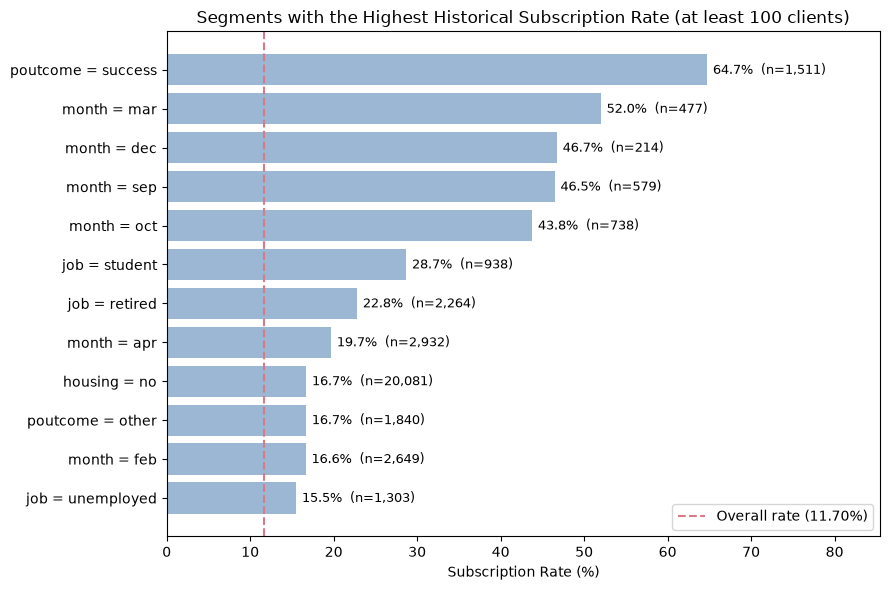

In [41]:
# Visual summary of the strongest segments. The dashed line marks the overall
# subscription rate, so every bar can be read against the average client.
top_segments_plot = customer_segments.head(12).sort_values("Subscription Rate (%)")

segment_labels = (
    top_segments_plot["Segment Variable"]
    + " = "
    + top_segments_plot["Segment Value"].astype(str)
)

plt.figure(figsize=(9, 6))

bars = plt.barh(segment_labels, top_segments_plot["Subscription Rate (%)"], color="#9BB7D4")

plt.axvline(
    overall_subscription_rate,
    color="#D97A8A",
    linestyle="--",
    label=f"Overall rate ({overall_subscription_rate:.2f}%)"
)

for bar, clients in zip(bars, top_segments_plot["Number of Clients"]):
    plt.text(
        bar.get_width() + 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%  (n={clients:,})",
        va="center",
        fontsize=9
    )

plt.title("Segments with the Highest Historical Subscription Rate (at least 100 clients)")
plt.xlabel("Subscription Rate (%)")
plt.xlim(0, top_segments_plot["Subscription Rate (%)"].max() * 1.32)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The chart shows the twelve strongest segments together with the number of clients behind each bar. Every bar is compared with the dashed line, which marks the overall subscription rate of 11.70%.

The comparison also shows why the number of clients has to be reported next to the rate. The segment `poutcome = success` reaches 64.73% but contains 1,511 clients, and `month = mar` reaches 51.99% with 477 clients, while `housing = no` reaches a much lower 16.70% but covers 20,081 clients. A high rate in a small group and a moderate rate in a very large group are useful in different ways: the first identifies a precise target, and the second describes a large part of the client base.

### 2. Important Features

The influential features are taken from the Decision Tree that was trained in Part E. Feature importance measures how much each column contributed to separating subscribers from non-subscribers across all the splits of the tree; the values sum to 1. Because importance alone does not show the direction of the relationship, every feature is presented together with evidence computed from the dataset: the historical subscription rate of the corresponding category, or, for a numerical feature, its correlation with the subscription outcome.

In [42]:
# Influential features of the Decision Tree. The fitted model and the names of
# the preprocessed columns were stored in Part E, so nothing is retrained here.
feature_importance = pd.DataFrame({
    "Feature": decision_tree_feature_names,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Evidence is taken from the data itself: a one-hot column is matched to the
# historical subscription rate of its category, and a numerical feature to its
# correlation with the outcome. This supplies the direction of the relationship,
# which the importance value alone does not show.
segment_lookup = {
    (row["Segment Variable"], str(row["Segment Value"]).lower()):
        (row["Subscription Rate (%)"], row["Number of Clients"])
    for _, row in segment_rates.iterrows()
}


def feature_evidence(feature_name):
    """Return the computed evidence and interpretation for one encoded column."""
    if feature_name.startswith("num__"):
        column = feature_name[len("num__"):]
        correlation = segment_df[column].corr(segment_df["y_numeric"])
        direction = "higher" if correlation > 0 else "lower"
        return (
            f"correlation with subscription = {correlation:+.3f}",
            f"a larger {column} goes together with a {direction} chance of subscribing"
        )

    for column in categorical_features:
        prefix = f"cat__{column}_"
        if feature_name.startswith(prefix):
            value = feature_name[len(prefix):]
            rate, clients = segment_lookup[(column, value.lower())]
            comparison = "above" if rate > overall_subscription_rate else "below"
            return (
                f"{column} = {value}: {rate:.2f}% of {clients:,} clients subscribed",
                f"{rate:.2f}% is {comparison} the overall rate of {overall_subscription_rate:.2f}%"
            )

    return ("not available", "not available")


# Only the columns the tree actually used are reported, together with their evidence.
top_features = feature_importance[feature_importance["Importance"] > 0].head(10).copy()

evidence_rows = [feature_evidence(name) for name in top_features["Feature"]]
top_features["Evidence"] = [evidence for evidence, _ in evidence_rows]
top_features["Interpretation"] = [interpretation for _, interpretation in evidence_rows]

print("Columns produced by the preprocessing step:", len(decision_tree_feature_names))
print("Columns actually used by the trained tree:",
      int((decision_tree_model.feature_importances_ > 0).sum()))

top_features.round(4)

Columns produced by the preprocessing step: 50
Columns actually used by the trained tree: 14


,Feature,Importance,Evidence,Interpretation
0,cat__poutcome_success,0.4131,"poutcome = success: 64.73% of 1,511 clients su...",64.73% is above the overall rate of 11.70%
1,cat__contact_Unknown,0.2356,"contact = Unknown: 4.07% of 13,020 clients sub...",4.07% is below the overall rate of 11.70%
2,cat__housing_no,0.1098,"housing = no: 16.70% of 20,081 clients subscribed",16.70% is above the overall rate of 11.70%
3,cat__month_aug,0.0673,"month = aug: 11.01% of 6,247 clients subscribed",11.01% is below the overall rate of 11.70%
4,cat__month_jul,0.0630,"month = jul: 9.09% of 6,895 clients subscribed",9.09% is below the overall rate of 11.70%
5,num__campaign,0.0276,correlation with subscription = -0.073,a larger campaign goes together with a lower c...
6,cat__month_jun,0.0264,"month = jun: 10.22% of 5,341 clients subscribed",10.22% is below the overall rate of 11.70%
7,num__pdays,0.0241,correlation with subscription = +0.104,a larger pdays goes together with a higher cha...
8,cat__marital_married,0.0128,"marital = married: 10.12% of 27,214 clients su...",10.12% is below the overall rate of 11.70%
9,cat__month_may,0.0093,"month = may: 6.72% of 13,766 clients subscribed",6.72% is below the overall rate of 11.70%


The Decision Tree feature importance results show that `poutcome_success` was the most influential feature, with an importance value of 0.4131. This indicates that a successful outcome in a previous marketing campaign had a strong influence on the model's predictions. The evidence column confirms the direction: 64.73% of the 1,511 clients in this group subscribed, which is far above the overall rate of 11.70%.

The second most important feature was `contact_Unknown`, with an importance value of 0.2356, followed by `housing_no` with 0.1098. The computed evidence shows that these two features work in opposite directions. Among the 13,020 clients whose contact type was not recorded, only 4.07% subscribed, which is well below the overall rate, so the model uses this column as a negative signal. Among the 20,081 clients without a housing loan, 16.70% subscribed, which is above the overall rate, so this column acts as a positive signal.

Several month-related features also contributed to the model, including August (0.0673), July (0.0630), and June (0.0264). Their subscription rates, 11.01%, 9.09% and 10.22%, are close to or slightly below the overall rate, which shows that the tree does not use these months as strong positive signals but as conditions that help separate clients inside a branch. The same applies to `month_may` and `marital_married`.

The numerical variable `campaign` had an importance value of 0.0276 and a negative correlation with the outcome (-0.073), meaning that clients who were contacted many times during the campaign subscribed slightly less often. The variable `pdays` had an importance value of 0.0241 and a positive correlation (+0.104), which is consistent with the fact that a value of -1 marks clients who were never contacted in a previous campaign.

Only 14 of the 50 encoded columns received an importance above zero, which is a direct consequence of limiting the tree to a depth of five. Overall, the results suggest that previous campaign outcome, whether a contact channel was recorded, housing status, and campaign timing were the main factors used by the Decision Tree when making predictions.

These values describe how the model behaves and which patterns exist in the historical data. They do not prove that a variable causes a client to subscribe.

### 3. Error Analysis

The two error types are counted from the confusion matrices of Part G, using the same test-set predictions.

In [43]:
from sklearn.metrics import confusion_matrix

# Error analysis. The two error types are counted from the same test-set
# predictions that were evaluated in Part G.
dt_cm = confusion_matrix(y_test, decision_tree_predictions)
knn_cm = confusion_matrix(y_test, knn_predictions)

# ravel() returns the cells of a binary confusion matrix in the order
# true negatives, false positives, false negatives, true positives.
dt_tn, dt_fp, dt_fn, dt_tp = dt_cm.ravel()
knn_tn, knn_fp, knn_fn, knn_tp = knn_cm.ravel()

error_analysis = pd.DataFrame({
    "Model": ["Decision Tree", "kNN"],
    "False Positives": [dt_fp, knn_fp],
    "False Negatives": [dt_fn, knn_fn],
    "True Positives": [dt_tp, knn_tp],
    "True Negatives": [dt_tn, knn_tn]
})

error_analysis

,Model,False Positives,False Negatives,True Positives,True Negatives
0,Decision Tree,1383,464,594,6602
1,kNN,169,849,209,7816


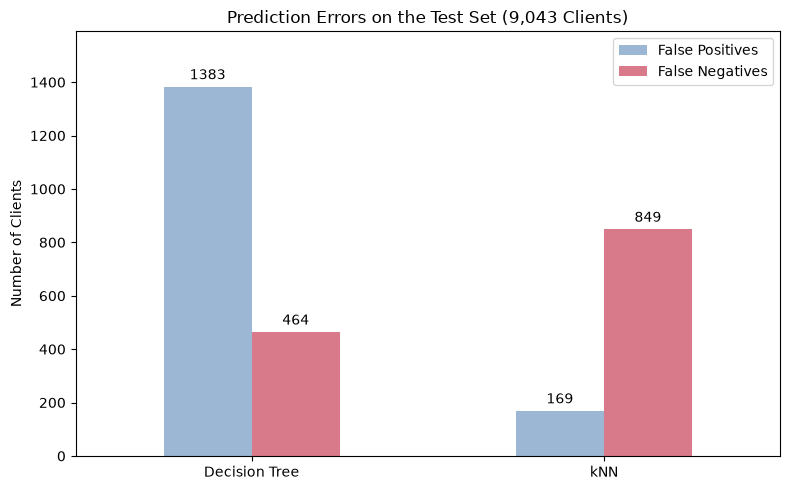

In [44]:
# The two error types side by side, using the counts computed above.
error_plot = error_analysis.set_index("Model")[["False Positives", "False Negatives"]]

ax = error_plot.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#9BB7D4", "#D97A8A"],
    rot=0
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_title(f"Prediction Errors on the Test Set ({len(y_test):,} Clients)")
ax.set_ylabel("Number of Clients")
ax.set_xlabel("")
ax.set_ylim(0, error_plot.to_numpy().max() * 1.15)

plt.tight_layout()
plt.show()

A false positive occurs when the model predicts that a client will subscribe, although the client actually does not. This may lead to unnecessary marketing contacts and wasted resources.

A false negative occurs when the model predicts that a client will not subscribe, although the client actually would have subscribed. This may cause the bank to miss a potential customer.

The Decision Tree produced 1,383 false positives and 464 false negatives. In comparison, kNN produced only 169 false positives but 849 false negatives. The chart above shows the same result: the two models make almost opposite mistakes, and the total number of errors is similar, but they are distributed differently between the two types.

This shows that kNN makes fewer unnecessary positive predictions, but it misses many more actual subscribers. If the bank's main goal is to identify as many potential subscribers as possible, false negatives are more costly because they represent missed business opportunities.

It should be stated clearly that the dataset contains no information about the cost of a phone call or about the profit generated by a term deposit. The comparison above is therefore based on the counted errors, while the conclusion about which error is more costly is a business interpretation that depends on the objective of the bank and not on a monetary value computed from the data.

### 4. Model Recommendation

**Recommended model: Decision Tree**

The Decision Tree is recommended for practical use when the bank's main goal is to identify as many potential subscribers as possible.

Although kNN achieved higher accuracy and precision, its recall for the positive class was much lower. The Decision Tree achieved a recall of 0.5614, compared with 0.1975 for kNN. This means that the Decision Tree identified a much larger proportion of clients who actually subscribed.

The Decision Tree also achieved a higher F1-score for the positive class, 0.3914 compared with 0.2911 for kNN, indicating a better balance between precision and recall.

In addition, the Decision Tree is easier to interpret and explain to business users. Its feature importance values can also help explain which variables influenced the predictions.

Regarding the risk of overfitting, the recommended tree is deliberately restricted. As reported in Part E, it was trained with `max_depth=5` and `min_samples_leaf=20`, it reached a depth of five levels with 29 leaves, and it uses only 14 of the 50 encoded columns. Every rule of the model is therefore supported by at least 20 training clients, which limits how closely the model can follow the individual observations of the training set. kNN carries a different risk: it stores the training set and classifies each new client by the five nearest neighbours in a 50-dimensional space, where distances become less informative, as discussed in Part F.

Regarding the practicality of deployment, the Decision Tree is a small set of at most five conditions per client, so a prediction is a short sequence of comparisons and the rules can be printed and reviewed by the marketing department. kNN must keep all 36,168 training observations available and compute the distance to each of them for every client that is scored, which makes it heavier to run and impossible to summarize as a readable rule.

The main disadvantage is that the Decision Tree produces more false positives than kNN, which may increase unnecessary marketing contacts. However, if missing potential subscribers is considered more costly, the Decision Tree is the more useful model for this business objective.

### 5. Campaign Recommendations

In [45]:
from sklearn.metrics import precision_score, recall_score

# Campaign recommendations. Every line printed below is produced from values
# computed earlier - the segment table of section 1 and the Part G predictions -
# and the model comparisons use rule-based conditions rather than fixed text.
top_segments = customer_segments.head(5)

dt_precision = precision_score(y_test, decision_tree_predictions)
dt_recall = recall_score(y_test, decision_tree_predictions)

knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)

positive_rate = segment_df["y_numeric"].mean() * 100

# Evidence for the data-collection recommendation: how often the strongest
# available predictor is missing from the records.
unknown_poutcome_count = int((segment_df["poutcome"] == "unknown").sum())
unknown_poutcome_share = (segment_df["poutcome"] == "unknown").mean() * 100

print("Campaign Recommendations")
print()

print("1. High-subscription segments:")
for _, row in top_segments.iterrows():
    print(
        f"{row['Segment Variable']} = {row['Segment Value']}: "
        f"{row['Subscription Rate (%)']:.2f}% "
        f"({int(row['Number of Clients'])} clients)"
    )

print()
print(f"2. Overall subscription rate: {positive_rate:.2f}%")
print("Accuracy should not be used alone because the target is imbalanced.")

print()
print(
    f"3. Decision Tree recall: {dt_recall:.4f} | "
    f"kNN recall: {knn_recall:.4f}"
)

if dt_recall > knn_recall:
    print("Decision Tree is preferred when the goal is to identify more potential subscribers.")
else:
    print("kNN is preferred when the goal is to identify more potential subscribers.")

print()
print(
    f"4. Decision Tree precision: {dt_precision:.4f} | "
    f"kNN precision: {knn_precision:.4f}"
)

if dt_precision > knn_precision:
    print("Decision Tree is preferred when reducing unnecessary contacts is more important.")
else:
    print("kNN is preferred when reducing unnecessary contacts is more important.")

print()
print("5. Duration should not be used for pre-call prediction because it is not known before the call takes place.")

print()
print(
    f"6. The previous campaign outcome is unknown for {unknown_poutcome_count:,} clients "
    f"({unknown_poutcome_share:.2f}% of the dataset), while poutcome = success is both the "
    f"strongest segment ({customer_segments.iloc[0]['Subscription Rate (%)']:.2f}%) and the "
    f"most important feature of the tree ({feature_importance.iloc[0]['Importance']:.4f})."
)
print("Recording the outcome of every contact would make this information available for more clients in future campaigns.")

Campaign Recommendations

1. High-subscription segments:
poutcome = success: 64.73% (1511 clients)
month = mar: 51.99% (477 clients)
month = dec: 46.73% (214 clients)
month = sep: 46.46% (579 clients)
month = oct: 43.77% (738 clients)

2. Overall subscription rate: 11.70%
Accuracy should not be used alone because the target is imbalanced.

3. Decision Tree recall: 0.5614 | kNN recall: 0.1975
Decision Tree is preferred when the goal is to identify more potential subscribers.

4. Decision Tree precision: 0.3005 | kNN precision: 0.5529
kNN is preferred when reducing unnecessary contacts is more important.

5. Duration should not be used for pre-call prediction because it is not known before the call takes place.

6. The previous campaign outcome is unknown for 36,959 clients (81.75% of the dataset), while poutcome = success is both the strongest segment (64.73%) and the most important feature of the tree (0.4131).
Recording the outcome of every contact would make this information availabl

The campaign recommendations are based directly on the computed subscription rates and model evaluation results.

Clients with a successful previous campaign outcome had the highest subscription rate, at 64.73%. March also showed a high historical subscription rate of 51.99%, followed by December at 46.73%, September at 46.46%, and October at 43.77%.

The overall subscription rate in the dataset was only 11.70%, which confirms that the target is imbalanced. Therefore, accuracy alone should not be used when selecting a model.

The Decision Tree achieved a higher recall of 0.5614 compared with 0.1975 for kNN. Therefore, if the bank wants to identify as many potential subscribers as possible, the Decision Tree is more suitable.

In contrast, kNN achieved a higher precision of 0.5529 compared with 0.3005 for the Decision Tree. If reducing unnecessary marketing contacts is more important, kNN may be preferable.

For pre-call prediction, the duration feature should not be used because the duration of the future call is not known before the client is contacted.

The previous campaign outcome is unknown for 36,959 clients, which is 81.75% of the dataset, and this is exactly the variable that produced both the strongest segment and the most important feature of the tree. Recording the outcome of every contact would therefore make the most valuable available information usable for a much larger part of the client base in future campaigns.

These recommendations describe associations observed in historical campaign data, not proven causes. The months with the highest rates are also the months with the fewest calls: March contains 477 records and December 214, while May contains 13,766. Calling more clients in March would not necessarily reproduce a rate of 51.99%, because the clients contacted in those months may differ from the rest of the client base. The segment results should therefore be used to set priorities and to design a test campaign, not as a guarantee of the same outcome.

Overall, the bank should prioritize customer groups and campaign periods with higher historical subscription rates, while selecting the model according to the business objective and the cost of different prediction errors.

# Part I – Business Interpretation

1. kNN achieved higher accuracy (0.8874 versus 0.7958) and precision (0.5529 versus 0.3005), while the Decision Tree achieved higher recall (0.5614 versus 0.1975) and F1-score (0.3914 versus 0.2911). No model was better on every metric, but the Decision Tree is more useful when the objective is to identify more actual subscribers.

2. The Decision Tree achieved the higher recall: 0.5614 compared with 0.1975 for kNN. Of the 1,058 actual subscribers in the test set, the Decision Tree correctly identified 594 and missed 464, whereas kNN identified 209 and missed 849.

3. kNN achieved the higher precision: 0.5529 compared with 0.3005 for the Decision Tree. It produced 169 false positives, compared with 1,383 from the Decision Tree, so a larger share of its positive predictions was correct.

4. Accuracy is useful but should not be used alone because only 11.70% of the dataset subscribed. kNN illustrates this limitation: despite an accuracy of 0.8874, its recall was 0.1975 and it missed 849 actual subscribers. Precision, recall, F1-score, and the confusion matrix are therefore also needed.

5. A false positive is a client predicted to subscribe who did not subscribe. The Decision Tree produced 1,383 false positives and kNN produced 169. These errors can lead to contacts with clients who do not subscribe.

6. A false negative is an actual subscriber predicted not to subscribe. The Decision Tree produced 464 false negatives and kNN produced 849, representing potential subscribers that each model failed to identify.

7. The dataset does not provide call costs or term-deposit profits, so neither error can be assigned a computed monetary cost. If the objective is to miss fewer potential subscribers, false negatives matter more and the Decision Tree is preferable because it produced 464 rather than 849. If avoiding unnecessary contacts is the priority, false positives matter more and kNN performs better with 169 rather than 1,383.

8. The Decision Tree is recommended for this project's objective because it identified 594 actual subscribers, compared with 209 for kNN, and achieved higher recall (0.5614) and F1-score (0.3914). It is also easier to interpret through feature importance: `poutcome_success` was most important at 0.4131, followed by `contact_Unknown` at 0.2356 and `housing_no` at 0.1098. Its main disadvantage is the much larger number of false positives.

9. The recommendation is limited by the Decision Tree's lower accuracy and precision and its 1,383 false positives: only 594 of its 1,977 positive predictions were correct. The results are based on historical campaign data, one train/test split, and one tested setting for each model, so future results may differ and the Part H segment rates show associations rather than causes. The preferred model also depends on the business objective. `duration` was excluded because a future call's duration is unavailable before contact, so these results describe a pre-call prediction setting.

10. The bank could use the model results together with the historical segment analysis to prioritize future campaigns. The highest observed rate was for `poutcome = success` at 64.73% among 1,511 clients. March reached 51.99%, December 46.73%, September 46.46%, and October 43.77%. Students reached 28.68%, retired clients 22.79%, unemployed clients 15.50%, clients with tertiary education 15.01%, and clients without a housing loan 16.70%. The Decision Tree is suitable when finding more potential subscribers is the priority, while kNN may be considered when reducing unnecessary contacts is more important. Because previous campaign outcome is unknown for 81.75% of clients, consistently recording contact outcomes would make this important predictor available for more future cases.

# Part J – Ethics, Limitations, and Practical Risks

**Fairness.** The models use client characteristics such as `age`, `job`, `marital`, and `education` as input features, so a decision about whom to contact is partly based on these attributes. The subscription rates computed in Part H differ considerably between such groups, for example 28.68% for students against an overall rate of 11.70%, so a campaign that follows the model would contact some groups far more often than others. This is a difference in treatment that is visible in the data. Error rates were not computed separately for each group in this project, so no claim is made here that the model is unfair towards any particular group; establishing that would require a group-level evaluation of precision and recall.

**Bias.** The training data record how the bank ran its earlier campaigns, and not only how clients behave. The previous campaign outcome is unknown for 81.75% of the clients, the contact channel was not recorded for a large part of the dataset, and the number of calls differs greatly between months. The model therefore partly learns the bank's own past targeting decisions, and if future campaigns follow its predictions the same pattern can reinforce itself over time. Historical associations should also not be treated as proof that group membership causes subscription.

**Privacy.** The dataset contains personal customer and campaign information, including age, job, education, financial attributes, and contact history. These data should be accessed only for the project purpose, stored securely, and shared carefully. Only information needed for prediction and evaluation should be used.

**Data leakage.** Call duration is known only after a call has taken place. Using it to predict which customers to contact before a future call could leak information that is unavailable at prediction time and produce an unrealistic evaluation. The current main model excludes `duration`, making it suitable for the intended pre-call setting.

**Practical limitations.** The reported results come from this dataset, one train/test split, and the tested Decision Tree and kNN settings; future campaign conditions and customer behaviour may change. Predictions should support targeting and human business judgment, not automatically replace decisions. The bank should monitor model performance, group-level effects, and data quality over time, and review or retrain the model when its results no longer remain reliable.